# Visualization of Gaussian RBF vs Fractalized Gaussian RBF

This notebook compares the standard Gaussian Radial Basis Function (RBF) with its fractalized variant computed via `alpha_fractalize` and its derivative via `alpha_fractalize_first_derivative`.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from src.alpha_fractal_function import (
    alpha_fractalize,
    alpha_fractalize_first_derivative,
    pointwise_fractal
)

In [ ]:
# 1. Define Gaussian RBF
gamma = 1.0
def rbf_f(x):
    return x**2 # np.exp(-gamma * (x ** 2))

def rbf_f_derivative(x):
    return -2.0 * gamma * x * np.exp(-gamma * (x ** 2))

# Domain [a, b]
a, b = -2.0, 2.0

# Base linear function g(x) matching boundary conditions: g(a)=f(a) and g(b)=f(b)
f_a, f_b = rbf_f(a), rbf_f(b)
def rbf_g(x):
    return f_a + (f_b - f_a) * (x - a) / (b - a)

def rbf_g_derivative(x):
    # Constant slope
    return np.full_like(x, (f_b - f_a) / (b - a))

# Hyperparameters for fractalization
subintervals = 6
alpha = [0.2, 0.1, 0.05, 0.05, 0.1, 0.2]
iterations = 6

# Pre-calculate fractal representations
fractal_f = alpha_fractalize(rbf_f, rbf_g, a, b, subintervals, alpha, iterations)
fractal_f_d = alpha_fractalize_first_derivative(rbf_f, rbf_g, a, b, subintervals, alpha, iterations)

f(-1) = 0.01831563888873418, f(1) = 0.01831563888873418
g(-1) = 0.01831563888873418, g(1) = 0.01831563888873418


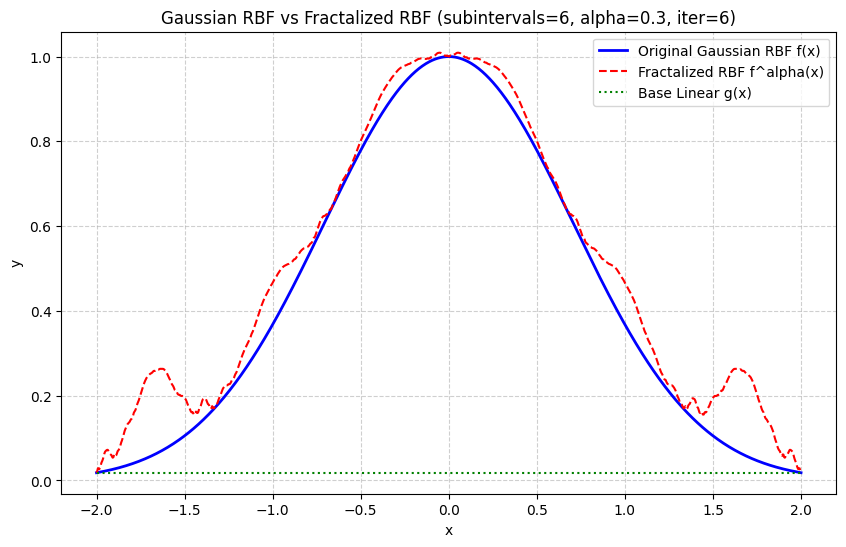

In [ ]:
# Dense grid for plotting
x_grid = np.linspace(a, b, 1000)
y_original = rbf_f(x_grid)
y_base_g = rbf_g(x_grid)
y_fractal = pointwise_fractal(x_grid, fractal_f)

# Plot Function Comparison
plt.figure(figsize=(10, 6))
plt.plot(x_grid, y_original, 'b-', label='Original Gaussian RBF f(x)', linewidth=2)
plt.plot(x_grid, y_fractal, 'r--', label='Fractalized RBF f^alpha(x)', linewidth=1.5)
plt.title(f'Gaussian RBF vs Fractalized RBF (subintervals={subintervals}, alpha=0.3, iter={iterations})')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

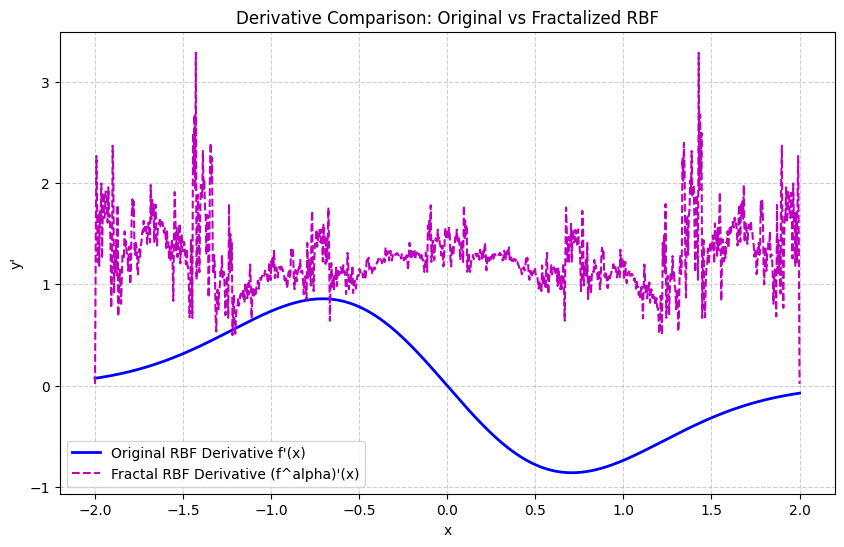

In [14]:
# Compute derivatives
dy_original = rbf_f_derivative(x_grid)
dy_fractal = pointwise_fractal(x_grid, fractal_f_d)

# Plot Derivative Comparison
plt.figure(figsize=(10, 6))
plt.plot(x_grid, dy_original, 'b-', label="Original RBF Derivative f'(x)", linewidth=2)
plt.plot(x_grid, dy_fractal, 'm--', label="Fractal RBF Derivative (f^alpha)'(x)", linewidth=1.5)
plt.title("Derivative Comparison: Original vs Fractalized RBF")
plt.xlabel('x')
plt.ylabel("y'")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

f(-1) = 0.01831563888873418, f(1) = 0.01831563888873418
g(-1) = 0.01831563888873418, g(1) = 0.01831563888873418
f(-1) = 0.01831563888873418, f(1) = 0.01831563888873418
g(-1) = 0.01831563888873418, g(1) = 0.01831563888873418
f(-1) = 0.01831563888873418, f(1) = 0.01831563888873418
g(-1) = 0.01831563888873418, g(1) = 0.01831563888873418


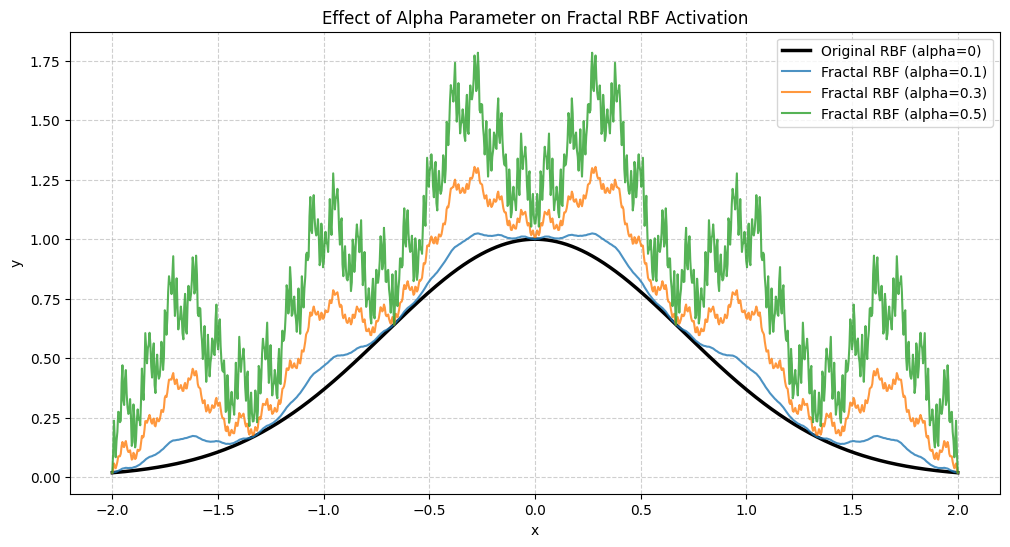

In [15]:
# Compare effect of different alpha scaling parameters
alpha_values = [0.1, 0.3, 0.5]

plt.figure(figsize=(12, 6))
plt.plot(x_grid, y_original, 'k-', label='Original RBF (alpha=0)', linewidth=2.5)

for val in alpha_values:
    a_arr = [val] * subintervals
    fr_dict = alpha_fractalize(rbf_f, rbf_g, a, b, subintervals, a_arr, iterations)
    y_fr = pointwise_fractal(x_grid, fr_dict)
    plt.plot(x_grid, y_fr, label=f'Fractal RBF (alpha={val})', alpha=0.8)

plt.title('Effect of Alpha Parameter on Fractal RBF Activation')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()